# 🔍 00b — Diagnóstico de Precision Baja

Ejecuta este notebook y pega el output completo. El objetivo es entender por qué la Precision es 0.10 y qué hay que cambiar.

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import precision_recall_curve, roc_auc_score
from sklearn.calibration import calibration_curve
warnings.filterwarnings('ignore')

base_dir   = os.path.dirname(os.getcwd())
silver_dir = os.path.join(base_dir, 'data', 'silver')
models_dir = os.path.join(base_dir, 'data', 'models')

FAMILIES = {
    'yaw_cable':   {'lead_hours': 72,  'color': '#378ADD'},
    'generator':   {'lead_hours': 120, 'color': '#D85A30'},
    'brake_hydro': {'lead_hours': 120, 'color': '#BA7517'},
    'pitch_bat':   {'lead_hours': 336, 'color': '#1D9E75'},
}
print('OK')


OK


## 1. Distribución real de probabilidades predichas

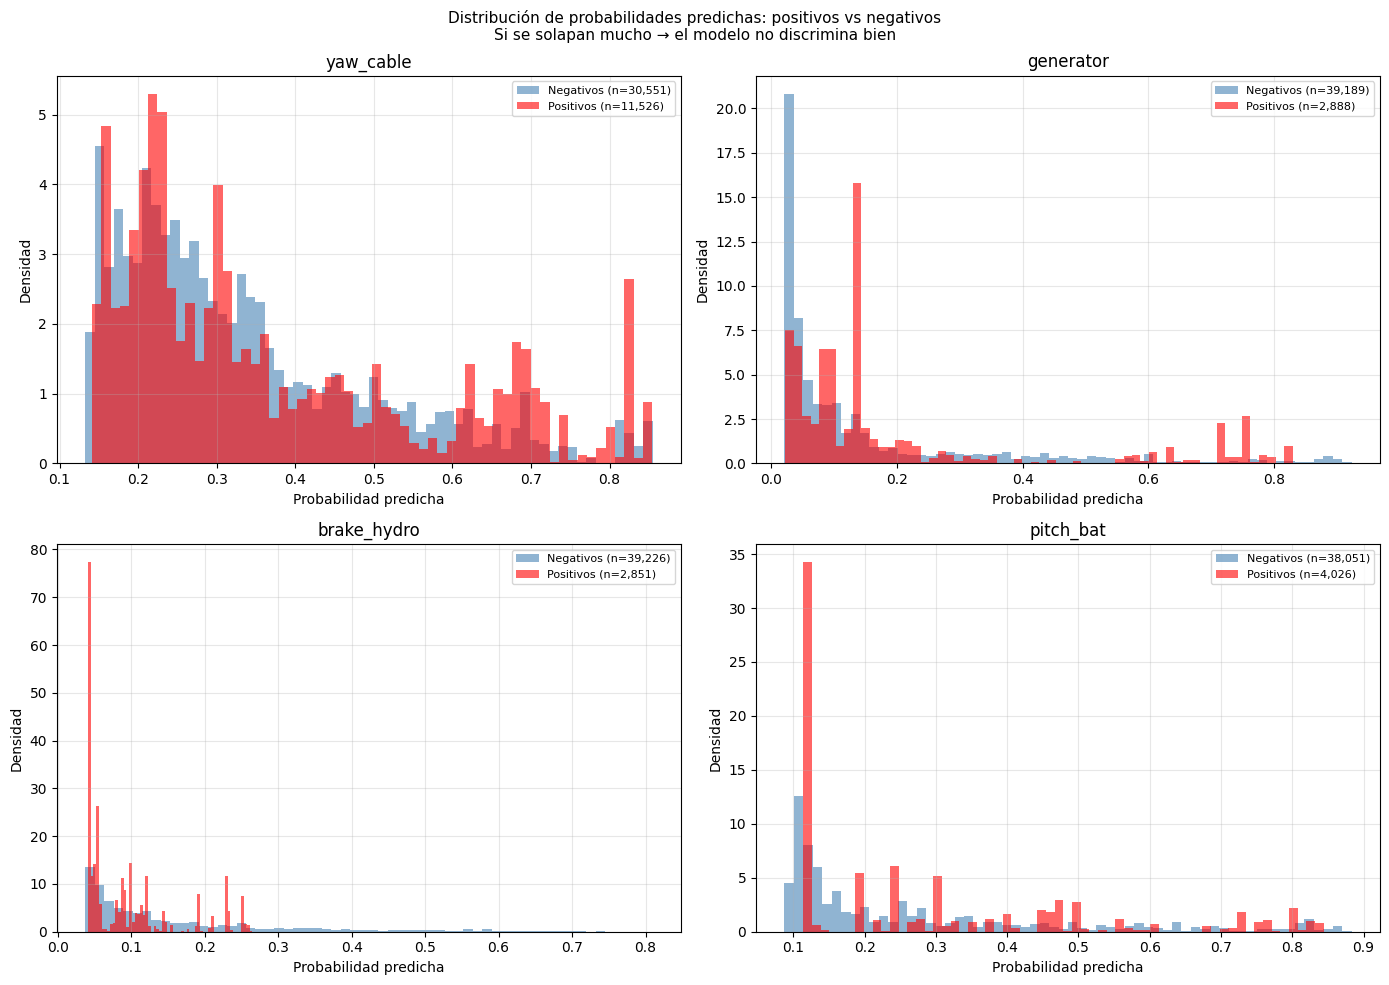

In [2]:
import pickle

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

prob_data = {}

for idx, (family, cfg) in enumerate(FAMILIES.items()):
    ax = axes[idx]
    # Cargar features y modelo
    feat_path = os.path.join(silver_dir, f'features_{family}.parquet')
    model_path = os.path.join(models_dir, f'model_{family}.pkl')
    if not os.path.exists(feat_path) or not os.path.exists(model_path):
        print(f'{family}: archivos no encontrados')
        continue

    df = pd.read_parquet(feat_path).sort_values('timestamp').reset_index(drop=True)
    target_col = f'is_pre_{family}'
    hours_col  = f'hours_to_{family}'
    feature_cols = [c for c in df.columns if c not in ['timestamp', target_col, hours_col]]

    cutoff = df['timestamp'].quantile(0.80)
    test   = df[df['timestamp'] >= cutoff].copy()
    X_test = test[feature_cols].fillna(0)
    y_test = test[target_col].astype(int)

    model  = pickle.load(open(model_path, 'rb'))
    y_prob = model.predict_proba(X_test)[:, 1]
    prob_data[family] = {'y_prob': y_prob, 'y_test': y_test, 'test': test,
                         'feature_cols': feature_cols, 'model': model}

    # Histograma separado positivos vs negativos
    ax.hist(y_prob[y_test == 0], bins=60, alpha=0.6, color='steelblue',
            label=f'Negativos (n={( y_test==0).sum():,})', density=True)
    ax.hist(y_prob[y_test == 1], bins=60, alpha=0.6, color='red',
            label=f'Positivos (n={(y_test==1).sum():,})', density=True)
    ax.set_xlabel('Probabilidad predicha')
    ax.set_ylabel('Densidad')
    ax.set_title(f'{family}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Distribución de probabilidades predichas: positivos vs negativos\n'
             'Si se solapan mucho → el modelo no discrimina bien', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'diag_prob_distributions.png'), dpi=150)
plt.show()


## 2. Estadísticos de probabilidades por clase

In [3]:
print(f'{"Familia":<15} {"Neg mean":>9} {"Neg p95":>9} {"Pos mean":>9} {"Pos p05":>9} {"Solapamiento":>13}')
print('-' * 70)
for family, d in prob_data.items():
    y_prob = d['y_prob']; y_test = d['y_test']
    neg = y_prob[y_test == 0]
    pos = y_prob[y_test == 1]
    neg_mean = neg.mean(); neg_p95 = np.percentile(neg, 95)
    pos_mean = pos.mean(); pos_p05 = np.percentile(pos, 5)
    # Solapamiento: % de negativos por encima del p05 de positivos
    overlap = 100 * (neg > pos_p05).mean()
    print(f'{family:<15} {neg_mean:>9.3f} {neg_p95:>9.3f} {pos_mean:>9.3f} {pos_p05:>9.3f} {overlap:>12.1f}%')

print()
print('Neg mean: media prob de los negativos (deberia ser baja)')
print('Pos p05: percentil 5 de los positivos (deberia ser alto)')
print('Solapamiento: % negativos que superan el p05 de positivos (deberia ser bajo)')


Familia          Neg mean   Neg p95  Pos mean   Pos p05  Solapamiento
----------------------------------------------------------------------
yaw_cable           0.335     0.688     0.372     0.159         91.5%
generator           0.147     0.596     0.204     0.022         84.5%
brake_hydro         0.157     0.502     0.093     0.042         91.0%
pitch_bat           0.264     0.753     0.297     0.115         76.7%

Neg mean: media prob de los negativos (deberia ser baja)
Pos p05: percentil 5 de los positivos (deberia ser alto)
Solapamiento: % negativos que superan el p05 de positivos (deberia ser bajo)


## 3. ¿Cuántos falsos positivos son 'casi siempre altos' (ruido estructural)?

In [4]:
# Si ciertos timestamps tienen siempre probabilidad alta independientemente del target,
# el modelo está aprendiendo algo estructural del dataset (hora del día, estación, etc.)
# y no degradación real.

print('Análisis de falsos positivos persistentes:')
print()
for family, d in prob_data.items():
    y_prob = d['y_prob']; y_test = d['y_test']
    test   = d['test']

    # FP: negativos con prob alta
    import json as _json
    with open(os.path.join(models_dir, f'results_{family}.json')) as f:
        res = _json.load(f)
    thr = res['threshold']

    fp_mask = (y_prob >= thr) & (y_test == 0)
    fp_ts   = test['timestamp'].values[fp_mask]

    if len(fp_ts) == 0:
        print(f'{family}: sin FP')
        continue

    # Distribución mensual de FP
    fp_df = pd.DataFrame({'timestamp': pd.to_datetime(fp_ts)})
    fp_monthly = fp_df.set_index('timestamp').resample('ME').size()
    neg_monthly = test[y_test.values == 0].set_index('timestamp').resample('ME').size()
    fp_rate = (fp_monthly / neg_monthly * 100).fillna(0)

    print(f'{family} (threshold={thr:.2f}): {fp_mask.sum():,} FP de {(y_test==0).sum():,} negativos ({100*fp_mask.mean():.1f}%)')
    print('  Tasa FP mensual:')
    for month, rate in fp_rate.items():
        print(f'    {month.strftime("%Y-%m")}: {rate:.1f}%')
    print()


Análisis de falsos positivos persistentes:

yaw_cable (threshold=0.13): 30,537 FP de 30,551 negativos (72.6%)
  Tasa FP mensual:
    2021-03: 100.0%
    2021-04: 100.0%
    2021-05: 100.0%
    2021-06: 100.0%
    2021-07: 99.6%
    2021-08: 100.0%
    2021-09: 100.0%
    2021-10: 100.0%
    2021-11: 100.0%
    2021-12: 100.0%

generator (threshold=0.06): 20,255 FP de 39,189 negativos (48.1%)
  Tasa FP mensual:
    2021-03: 4.6%
    2021-04: 75.8%
    2021-05: 55.5%
    2021-06: 73.6%
    2021-07: 61.4%
    2021-08: 68.5%
    2021-09: 58.8%
    2021-10: 23.1%
    2021-11: 44.0%
    2021-12: 41.2%

brake_hydro (threshold=0.20): 9,694 FP de 39,226 negativos (23.0%)
  Tasa FP mensual:
    2021-03: 17.8%
    2021-04: 26.9%
    2021-05: 38.4%
    2021-06: 3.8%
    2021-07: 1.1%
    2021-08: 6.5%
    2021-09: 4.3%
    2021-10: 24.7%
    2021-11: 47.8%
    2021-12: 58.7%

pitch_bat (threshold=0.10): 36,115 FP de 38,051 negativos (85.8%)
  Tasa FP mensual:
    2021-03: 100.0%
    2021-04: 100.0

## 4. Análisis de features: ¿hay features que solo son altas en ciertos períodos (proxy estacional)?

In [5]:
# Para generator y pitch_bat: verificar si las top features tienen correlación
# con la época del año (lo que causaría FP estacionales)

for family in ['generator', 'pitch_bat', 'brake_hydro']:
    if family not in prob_data:
        continue
    d = prob_data[family]
    test = d['test'].copy()
    test['prob'] = d['y_prob']
    test['month'] = pd.to_datetime(test['timestamp']).dt.month

    # Top 5 features por importancia
    model = d['model']
    fi = pd.Series(model.feature_importances_, index=d['feature_cols']).nlargest(5)

    print(f'=== {family}: correlación top features con mes del año ===')
    for feat in fi.index:
        if feat in test.columns:
            corr = test[feat].corr(test['month'])
            print(f'  {feat}: corr con mes = {corr:+.3f}')
    print()


=== generator: correlación top features con mes del año ===
  hours_since_last_generator: corr con mes = +0.277
  generator_bearing_rear_temperature_c__p95_7d: corr con mes = -0.211
  nacelle_temperature_c__std_7d: corr con mes = +0.167
  ambient_temperature_converter_c__p95_7d: corr con mes = -0.153
  t_rear_bearing_delta__p95_7d: corr con mes = -0.129

=== pitch_bat: correlación top features con mes del año ===
  hours_since_last_pitch_bat: corr con mes = -0.155
  motor_current_imbalance__p95_7d: corr con mes = -0.348
  motor_current_imbalance__exceed_7d: corr con mes = -0.153
  pitch_asymmetry__std_7d: corr con mes = +0.034
  blade_angle_pitch_position_a__exceed_7d: corr con mes = -0.089

=== brake_hydro: correlación top features con mes del año ===
  hours_since_last_brake_hydro: corr con mes = +0.147
  gear_oil_pump_pressure_bar__p95_7d: corr con mes = +0.169
  generator_rpm_standard_deviation_rpm__std_7d: corr con mes = -0.444
  t_gear_oil_delta__p95_7d: corr con mes = +0.084
  r

## 5. ¿El problema es el threshold o la separabilidad real de clases?

Familia           Max Prec (R>=0.80)  Threshold  AUC-ROC
------------------------------------------------------------
yaw_cable                      0.285      0.199    0.541
generator                      0.098      0.055    0.639
brake_hydro                    0.069      0.042    0.349
pitch_bat                      0.121      0.115    0.554


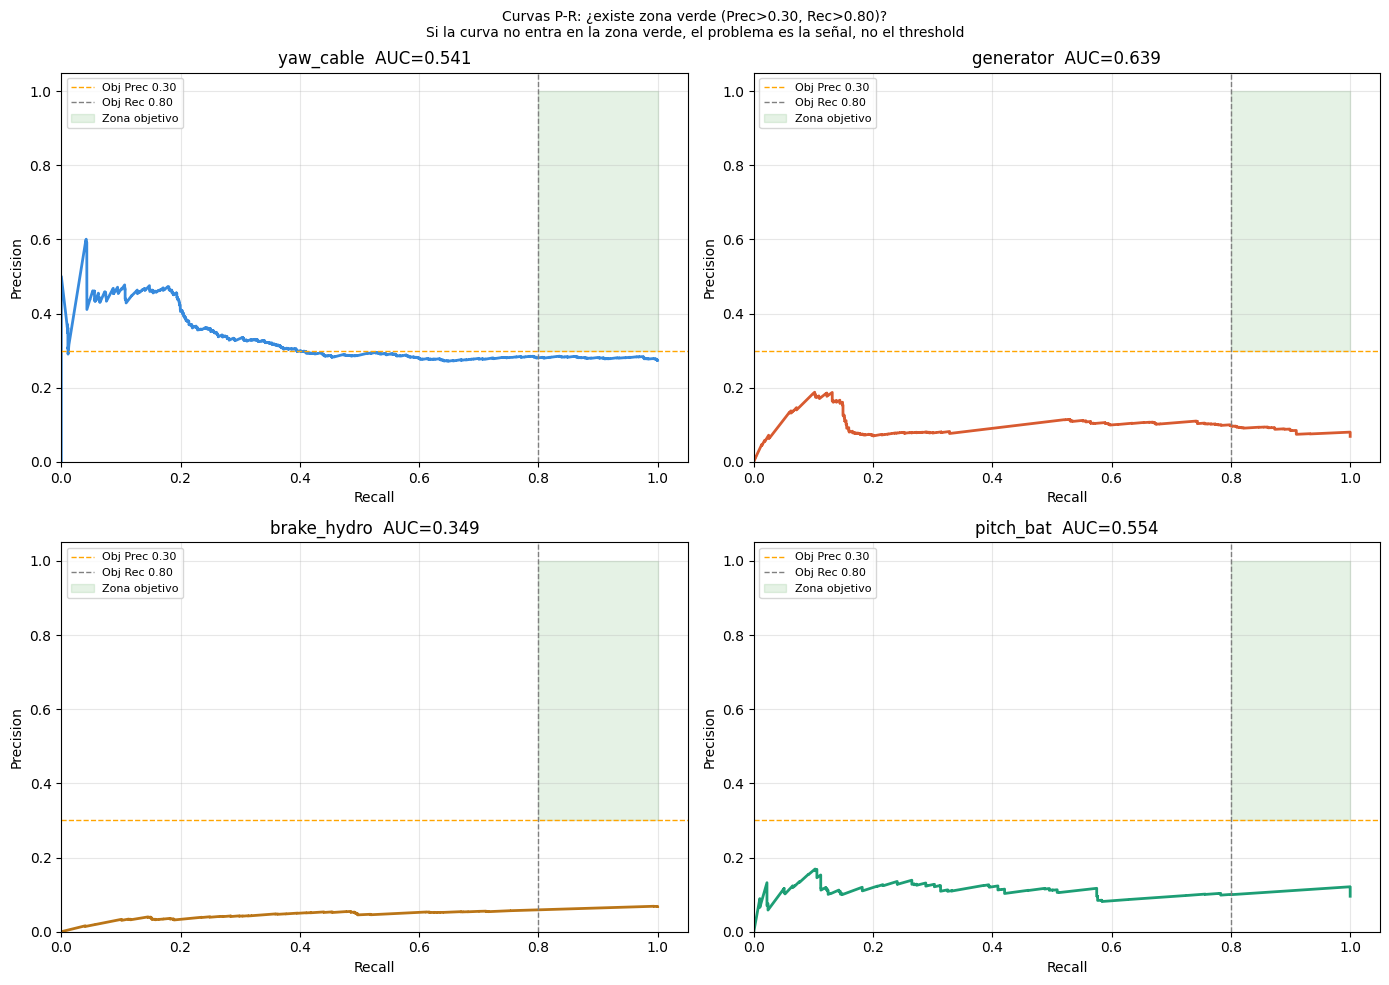

In [6]:
# Para cada familia: ¿cuál sería la Precision máxima alcanzable con Recall >= 0.80?
print(f'{"Familia":<15} {"Max Prec (R>=0.80)":>20} {"Threshold":>10} {"AUC-ROC":>8}')
print('-' * 60)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, (family, d) in enumerate(prob_data.items()):
    ax = axes[idx]
    y_prob = d['y_prob']; y_test = d['y_test']
    cfg = FAMILIES[family]

    prec, rec, thrs = precision_recall_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Max precision con recall >= 0.80
    mask = rec[:-1] >= 0.80
    if mask.any():
        max_prec_idx = np.argmax(prec[:-1][mask])
        max_prec = prec[:-1][mask][max_prec_idx]
        best_thr = thrs[mask][max_prec_idx]
    else:
        max_prec = 0.0; best_thr = 0.0

    print(f'{family:<15} {max_prec:>20.3f} {best_thr:>10.3f} {auc:>8.3f}')

    ax.plot(rec[:-1], prec[:-1], color=cfg['color'], linewidth=2)
    ax.axhline(0.30, color='orange', linestyle='--', linewidth=1, label='Obj Prec 0.30')
    ax.axvline(0.80, color='gray',   linestyle='--', linewidth=1, label='Obj Rec 0.80')
    ax.fill_between([0.80, 1.0], [0.30, 0.30], [1.0, 1.0], alpha=0.1, color='green',
                    label='Zona objetivo')
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{family}  AUC={auc:.3f}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle('Curvas P-R: ¿existe zona verde (Prec>0.30, Rec>0.80)?\n'
             'Si la curva no entra en la zona verde, el problema es la señal, no el threshold',
             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'diag_pr_curves_objetivo.png'), dpi=150)
plt.show()


## 6. Test de calibración

Calibración de probabilidades (reliability diagram):
Una curva cercana a la diagonal = bien calibrado
Curva por debajo de la diagonal = modelo subestima probabilidades (típico con class_weight=balanced)

yaw_cable: error de calibración medio = 0.198
  Prob predicha media: 0.345  |  Fracción real positivos: 0.274
generator: error de calibración medio = 0.401
  Prob predicha media: 0.151  |  Fracción real positivos: 0.069
brake_hydro: error de calibración medio = 0.425
  Prob predicha media: 0.153  |  Fracción real positivos: 0.068
pitch_bat: error de calibración medio = 0.342
  Prob predicha media: 0.267  |  Fracción real positivos: 0.096


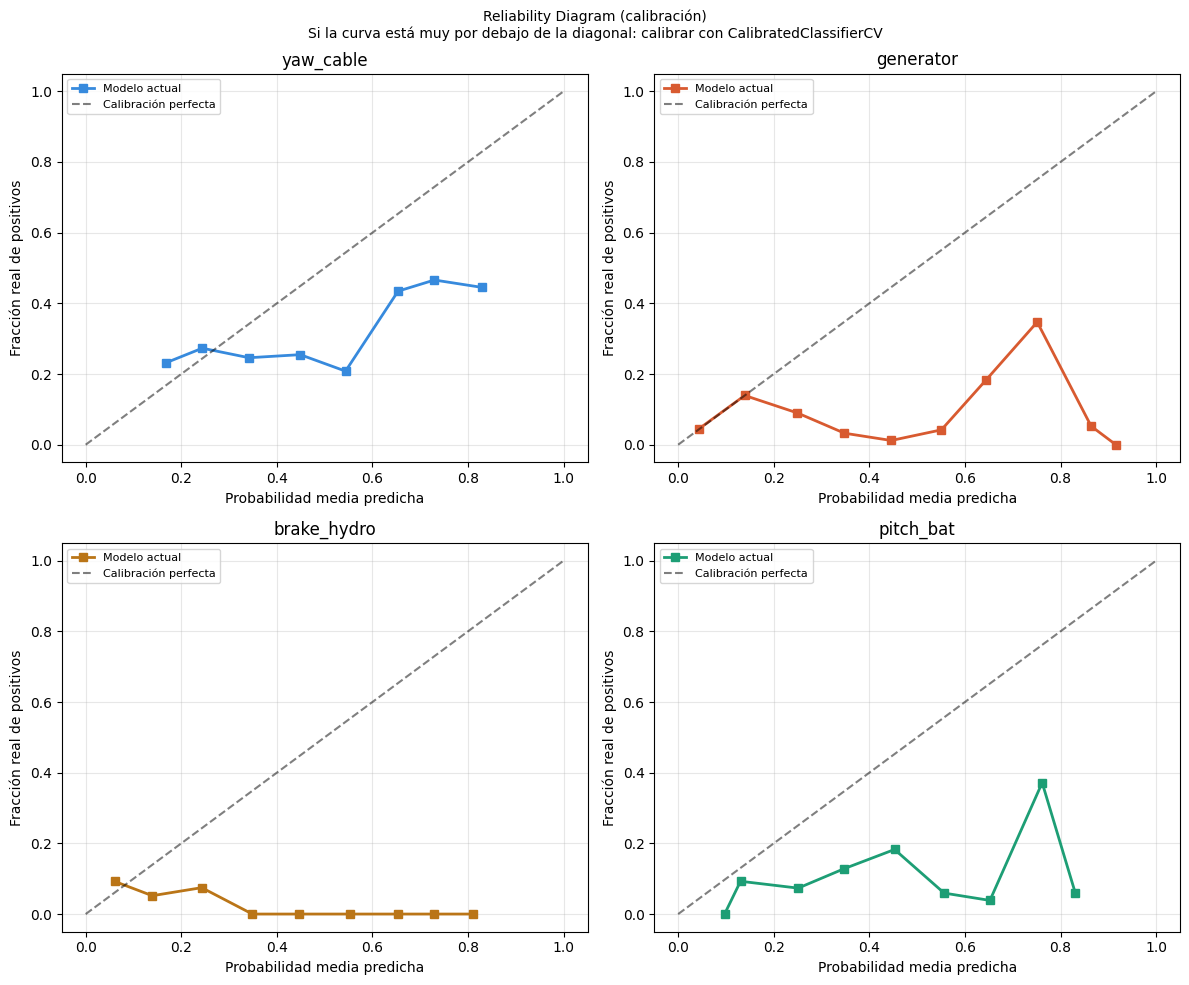

In [7]:
# Si el modelo está mal calibrado, una probabilidad predicha de 0.30 no significa
# '30% de probabilidad real de fallo'. La calibración alinea las probabilidades
# con las frecuencias reales observadas.

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

print('Calibración de probabilidades (reliability diagram):')
print('Una curva cercana a la diagonal = bien calibrado')
print('Curva por debajo de la diagonal = modelo subestima probabilidades (típico con class_weight=balanced)')
print()

for idx, (family, d) in enumerate(prob_data.items()):
    ax = axes[idx]
    y_prob = d['y_prob']; y_test = d['y_test']

    try:
        frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
        ax.plot(mean_pred, frac_pos, 's-', color=FAMILIES[family]['color'],
                linewidth=2, label='Modelo actual')
        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibración perfecta')
        ax.set_xlabel('Probabilidad media predicha')
        ax.set_ylabel('Fracción real de positivos')
        ax.set_title(f'{family}')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # Resumen numérico
        calibration_error = np.mean(np.abs(frac_pos - mean_pred))
        print(f'{family}: error de calibración medio = {calibration_error:.3f}')
        print(f'  Prob predicha media: {y_prob.mean():.3f}  |  Fracción real positivos: {y_test.mean():.3f}')
    except Exception as e:
        print(f'{family}: error en calibración — {e}')

fig.suptitle('Reliability Diagram (calibración)\n'
             'Si la curva está muy por debajo de la diagonal: calibrar con CalibratedClassifierCV',
             fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(models_dir, 'diag_calibration.png'), dpi=150)
plt.show()


## 7. ¿Cuántos FP se eliminarían con agregación temporal?

In [8]:
# Simular post-procesado: una alerta solo se confirma si la prob supera
# el threshold durante N intervalos consecutivos (10min cada uno)

print('Simulación de agregación temporal (N intervalos consecutivos):')
print(f'{"Familia":<15} {"Thr":>5} {"N=1 (actual)":>14} {"N=3 (30min)":>13} {"N=6 (1h)":>12} {"N=12 (2h)":>13}')
print('-' * 75)

import json as _json

for family, d in prob_data.items():
    y_prob = d['y_prob']; y_test = d['y_test']
    with open(os.path.join(models_dir, f'results_{family}.json')) as f:
        res = _json.load(f)
    thr = res['threshold']

    results_n = []
    for N in [1, 3, 6, 12]:
        # Señal agregada: media móvil de N pasos
        from scipy.ndimage import uniform_filter1d
        prob_smoothed = uniform_filter1d(y_prob.astype(float), size=N)
        y_pred = (prob_smoothed >= thr).astype(int)

        tp = ((y_pred == 1) & (y_test == 1)).sum()
        fp = ((y_pred == 1) & (y_test == 0)).sum()
        fn = ((y_pred == 0) & (y_test == 1)).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        results_n.append(f'P={prec:.2f}/R={rec:.2f}')

    print(f'{family:<15} {thr:>5.2f} {results_n[0]:>14} {results_n[1]:>13} {results_n[2]:>12} {results_n[3]:>13}')

print()
print('Si N=6 (1h) mejora Precision sin bajar Recall: la agregación temporal es la solución.')
print('Si Recall cae mucho al agregar: el modelo tiene muchos FP aislados difíciles de eliminar.')


Simulación de agregación temporal (N intervalos consecutivos):
Familia           Thr   N=1 (actual)   N=3 (30min)     N=6 (1h)     N=12 (2h)
---------------------------------------------------------------------------
yaw_cable        0.13  P=0.27/R=1.00 P=0.27/R=1.00 P=0.27/R=1.00 P=0.27/R=1.00
generator        0.06  P=0.10/R=0.78 P=0.10/R=0.78 P=0.10/R=0.78 P=0.10/R=0.78
brake_hydro      0.20  P=0.03/R=0.12 P=0.03/R=0.12 P=0.03/R=0.11 P=0.03/R=0.11
pitch_bat        0.10  P=0.10/R=1.00 P=0.10/R=1.00 P=0.10/R=1.00 P=0.10/R=1.00

Si N=6 (1h) mejora Precision sin bajar Recall: la agregación temporal es la solución.
Si Recall cae mucho al agregar: el modelo tiene muchos FP aislados difíciles de eliminar.


## 8. Resumen diagnóstico

In [9]:
print('=' * 70)
print('RESUMEN DIAGNÓSTICO — PRECISION BAJA')
print('=' * 70)
print()
print('Pega este output completo para determinar el plan de acción.')
print()
print('Las preguntas clave que responde este notebook:')
print('  1. ¿Se solapan las distribuciones de prob de positivos y negativos?')
print('     → Si sí: problema de señal. Si no: problema de threshold/calibración.')
print('  2. ¿Cuál es la Precision máxima alcanzable con Recall >= 0.80?')
print('     → Si < 0.30 en la curva P-R: el modelo no tiene suficiente señal.')
print('  3. ¿Está el modelo mal calibrado?')
print('     → Si sí: calibración con CalibratedClassifierCV sube Precision sin reentrenar.')
print('  4. ¿Mejora la Precision con agregación temporal?')
print('     → Si N=6 (1h) mejora Precision: post-procesado es la solución más rápida.')


RESUMEN DIAGNÓSTICO — PRECISION BAJA

Pega este output completo para determinar el plan de acción.

Las preguntas clave que responde este notebook:
  1. ¿Se solapan las distribuciones de prob de positivos y negativos?
     → Si sí: problema de señal. Si no: problema de threshold/calibración.
  2. ¿Cuál es la Precision máxima alcanzable con Recall >= 0.80?
     → Si < 0.30 en la curva P-R: el modelo no tiene suficiente señal.
  3. ¿Está el modelo mal calibrado?
     → Si sí: calibración con CalibratedClassifierCV sube Precision sin reentrenar.
  4. ¿Mejora la Precision con agregación temporal?
     → Si N=6 (1h) mejora Precision: post-procesado es la solución más rápida.
